## Load Library

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import signal, stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.autograd import Function
from math import sqrt

import time
import pickle
from sklearn.metrics import r2_score
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="networkx.utils.backends")


## MiTSformer training parameters (paper/repository-consistent defaults)


In [2]:
# Training settings
num_epochs = 100
save_every = 100
learning_rate = 0.001
batch_size = 64
model_num = 1
num_samples = 6560
duration = 15.47
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MiTSformer extrinsic-regression defaults in the official repository
d_model = 128
block_layers = 1
n_heads = 8
dropout = 0.1
activation = "gelu"

# Official auxiliary-loss weights
smooth_loss_w = 0.5
type_loss_w = 1.0
dis_rec_loss_w = 1.0
con_rec_loss_w = 1.0

# GPR-specific adaptation:
# Original MiTSformer expects multivariate mixed time series and predicts one scalar.
# The GPR A-scan is univariate and continuous. We therefore use the same A-scan
# as the observed continuous variable and generate one binary discrete variable
# using the official per-instance min-max normalization + 0.5 threshold rule.
# The original scalar-output regression head is extended to three outputs
# so that p1, c1, and d1 are jointly estimated using one MiTSformer model.
p_mixed = 2
dis_dim = 1
con_dim = 1

print(f"Device: {device}")


Device: cuda


## Load and processing data

### Simulated data

In [3]:
# Load cvs file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Single_Layer'
fname = os.path.join(data_dir, '1_layer_SimData_1547.csv')
SimData = pd.read_csv(fname).to_numpy()

In [4]:
# Seperate data and label
Sim_Data = SimData[:,3:]    
Sim_Label = SimData[:,0:3]

SimTime = np.arange(15.47/6560,15.47+15.47/6560,15.47/6560)[:-1] # Total time is 15.47 ns

SimTrain_Data = Sim_Data
SimTrain_Label = Sim_Label

In [5]:
# Check data size
print(SimTrain_Data.shape)
print(SimTrain_Label.shape)

(16500, 6560)
(16500, 3)


### Experimental data

In [6]:
fname = os.path.join(data_dir, '1_layer_TEST_ExpData.xlsx')
ExpTest = pd.read_excel(fname)

# Time
ExpTest_Time_1 = np.tile(ExpTest.iloc[2, 4:514].to_numpy(), (25,1))
ExpTest_Time_2 = np.tile(ExpTest.iloc[33, 4:514].to_numpy(), (25,1))
ExpTest_Time_3 = np.tile(ExpTest.iloc[65, 4:514].to_numpy(), (25,1))
ExpTest_Time_4 = np.tile(ExpTest.iloc[97, 4:514].to_numpy(), (25,1))
ExpTest_Time_5 = np.tile(ExpTest.iloc[129, 4:514].to_numpy(), (25,1))
ExpTest_Time_6 = np.tile(ExpTest.iloc[162, 4:514].to_numpy(), (25,1))
ExpTest_Time = np.concatenate((ExpTest_Time_1, ExpTest_Time_2, ExpTest_Time_3, ExpTest_Time_4,
                               ExpTest_Time_5, ExpTest_Time_6), axis=0)

# Label
ExpTest_Label_1 = ExpTest.iloc[3:28, 0:3].to_numpy()
ExpTest_Label_2 = ExpTest.iloc[34:59, 0:3].to_numpy()
ExpTest_Label_3 = ExpTest.iloc[66:91, 0:3].to_numpy()
ExpTest_Label_4 = ExpTest.iloc[98:123, 0:3].to_numpy()
ExpTest_Label_5 = ExpTest.iloc[130:155, 0:3].to_numpy()
ExpTest_Label_6 = ExpTest.iloc[163:188, 0:3].to_numpy()
ExpTest_Label = np.concatenate((ExpTest_Label_1, ExpTest_Label_2, ExpTest_Label_3, ExpTest_Label_4, 
                                ExpTest_Label_5, ExpTest_Label_6), axis=0)

# Data
ExpTest_Data_1 = ExpTest.iloc[3:28, 4:514].to_numpy()
ExpTest_Data_2 = ExpTest.iloc[34:59, 4:514].to_numpy()
ExpTest_Data_3 = ExpTest.iloc[66:91, 4:514].to_numpy()
ExpTest_Data_4 = ExpTest.iloc[98:123, 4:514].to_numpy()
ExpTest_Data_5 = ExpTest.iloc[130:155, 4:514].to_numpy()
ExpTest_Data_6 = ExpTest.iloc[163:188, 4:514].to_numpy()
ExpTest_Data = np.concatenate((ExpTest_Data_1, ExpTest_Data_2, ExpTest_Data_3, ExpTest_Data_4, 
                               ExpTest_Data_5, ExpTest_Data_6), axis=0)

In [7]:
# Check data size
print(ExpTest_Label.shape)
print(ExpTest_Data.shape)

(150, 3)
(150, 510)


### Processing dataset

In [8]:
# Process the signal to ensure a consistent duration and number of samples
def signal_processing(input_signal, time, duration, num_samples):
    idx = (np.abs(time - duration)).argmin()                       # Find the index corresponding to the specified duration
    truncate_siganl = input_signal[0:idx]                          # Truncate the signal to the specified duration
    output_signal = signal.resample(truncate_siganl, num_samples)  # Generate the signal with the specified number of samples
    return output_signal

# Normalize the signal using min-max normalization
def norm(input_signal):
    input_signal = input_signal/np.max(input_signal)
    return input_signal

# Shift signal to ensure the same start time in both simulated and experimental signals
def signal_shifting(sim_signal, exp_signal, sim_time, exp_time):
    sim_max_index = np.argmax(sim_signal)       # Find the index of the maximum value of simulated signal
    sim_max_time = sim_time[sim_max_index]      # Find the time of the maximum value of simulated signal
    exp_max_index = np.argmax(exp_signal)       # Find the index of the maximum value of experimental signal
    exp_max_time = exp_time[exp_max_index]      # Find the time of the maximum value of experimental signal
    time_diff = exp_max_time-sim_max_time       # Calcualte the time difference between simulated and experimental signals
    shift_index = np.absolute(exp_time-time_diff).argmin()    # Find the index of where the experimental signal should start
    exp_signal_shift = exp_signal[shift_index:]               # Remove the samples at the begining of the experimental signal
    exp_time_shift = exp_time[:len(exp_time)-shift_index]     # Update the time vector of the experimental signal
    return exp_signal_shift, exp_time_shift

In [9]:
unified_time = np.arange(duration/num_samples,duration+duration/num_samples,duration/num_samples)[:-1]
ExpTest_Data_Pro = np.zeros((ExpTest_Data.shape[0],num_samples))
SimTrain_Data_Pro = SimTrain_Data    # Simulated data already normalized

# Keep simulated data, upsample experimental data
for i in range(ExpTest_Data.shape[0]):
    exp_signal_shift, exp_time_shift = signal_shifting(SimTrain_Data[0], ExpTest_Data[i], SimTime, ExpTest_Time[i])
    ExpTest_Data_Pro[i] = norm(signal_processing(exp_signal_shift, exp_time_shift, duration, num_samples))

In [10]:
# Normalize the training labels
SimTrain_Label_Pro = np.zeros((SimTrain_Label.shape))

for i in range(SimTrain_Label.shape[1]):
    SimTrain_Label_Pro[:,i] = (SimTrain_Label[:,i] - np.min(SimTrain_Label[:,i])) /\
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i]))

In [11]:
# Check data size
print(ExpTest_Data_Pro.shape)

(150, 6560)


### Build data loader


In [12]:
# Keep the original preprocessed GPR A-scan and labels.
# The discrete/continuous MiTS streams are constructed inside the training loop.
SimTrain_Data_Pro_Tensor = torch.tensor(SimTrain_Data_Pro, dtype=torch.float32)
SimTrain_Label_Pro_Tensor = torch.tensor(SimTrain_Label_Pro, dtype=torch.float32)

Train_Dataset = TensorDataset(SimTrain_Data_Pro_Tensor, SimTrain_Label_Pro_Tensor)
Train_Loader = DataLoader(Train_Dataset, batch_size=batch_size, shuffle=True)

print("Training signal shape:", SimTrain_Data_Pro_Tensor.shape)
print("Training label shape:", SimTrain_Label_Pro_Tensor.shape)


Training signal shape: torch.Size([16500, 6560])
Training label shape: torch.Size([16500, 3])


**Implementation note.** This notebook retains the official MiTSformer architecture and auxiliary training objectives (latent-continuity recovery, variable-modality adversarial alignment, cascaded self-/cross-attention, discrete and continuous reconstruction, and smoothness regularization). The original MiTSformer extrinsic-regression head predicts one scalar. For the present GPR task, only the final regression layer is extended to three outputs so that relative permittivity ($p_1$), electrical conductivity ($c_1$), and layer depth ($d_1$) are estimated jointly. The GPR A-scan is retained as the continuous variable, while a per-instance min--max-normalized and thresholded copy is used as the discrete variable following the paper's discretization rule.


## Build MiTSformer extrinsic-regression model


In [13]:
class ReverseLayerF(Function):
    """Gradient reversal used by MiTSformer's variable-modality discriminator."""
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None


class SamePadConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        receptive_field = (kernel_size - 1) * dilation + 1
        padding = receptive_field // 2
        self.remove = 1 if receptive_field % 2 == 0 else 0
        self.conv = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )

    def forward(self, x):
        x = self.conv(x)
        if self.remove:
            x = x[:, :, :-self.remove]
        return x


class ConvBlock(nn.Module):
    """Residual dilated convolution block used in latent-continuity recovery."""
    def __init__(self, in_channels, out_channels, kernel_size, dilation, final=False):
        super().__init__()
        self.conv1 = SamePadConv(in_channels, out_channels, kernel_size, dilation)
        self.conv2 = SamePadConv(out_channels, out_channels, kernel_size, dilation)
        self.projector = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels or final else None
        )

    def forward(self, x):
        residual = x if self.projector is None else self.projector(x)
        x = F.gelu(x)
        x = self.conv1(x)
        x = F.gelu(x)
        x = self.conv2(x)
        return x + residual


class RecoverCNN(nn.Module):
    """Official MiTSformer latent-continuity recovery topology."""
    def __init__(self, in_channels=1, hidden_rec=128, n_layers=3, kernel_size=3):
        super().__init__()
        channels = [hidden_rec] * (n_layers - 1) + [1]
        self.net = nn.Sequential(*[
            ConvBlock(
                channels[i - 1] if i > 0 else in_channels,
                channels[i],
                kernel_size=kernel_size,
                dilation=2 ** i,
                final=(i == len(channels) - 1)
            )
            for i in range(len(channels))
        ])

    def forward(self, x):
        return self.net(x)


class FullAttention(nn.Module):
    """Scaled dot-product full attention used by the official implementation."""
    def __init__(self, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values):
        # queries: B x L x H x E
        scale = 1.0 / sqrt(queries.shape[-1])
        scores = torch.einsum("blhe,bshe->bhls", queries, keys)
        attn = self.dropout(torch.softmax(scale * scores, dim=-1))
        out = torch.einsum("bhls,bshd->blhd", attn, values)
        return out.contiguous(), attn


class AttentionLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        d_head = d_model // n_heads
        self.n_heads = n_heads
        self.query_projection = nn.Linear(d_model, d_head * n_heads)
        self.key_projection = nn.Linear(d_model, d_head * n_heads)
        self.value_projection = nn.Linear(d_model, d_head * n_heads)
        self.out_projection = nn.Linear(d_head * n_heads, d_model)
        self.inner_attention = FullAttention(dropout)

    def forward(self, queries, keys, values):
        B, L, _ = queries.shape
        S = keys.shape[1]
        H = self.n_heads

        q = self.query_projection(queries).view(B, L, H, -1)
        k = self.key_projection(keys).view(B, S, H, -1)
        v = self.value_projection(values).view(B, S, H, -1)

        out, attn = self.inner_attention(q, k, v)
        out = out.view(B, L, -1)
        return self.out_projection(out), attn


class VariableEmbedding(nn.Module):
    """Variable-wise embedding: B x D x T -> B x D x d_model."""
    def __init__(self, T, d_model, dropout=0.1):
        super().__init__()
        self.value_embedding = nn.Linear(T, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.value_embedding(x))


class Discriminator(nn.Module):
    """Variable-modality discriminator from the official MiTSformer."""
    def __init__(self, d_model):
        super().__init__()
        self.dis1 = nn.Linear(d_model, 4 * d_model)
        self.bn1 = nn.BatchNorm1d(4 * d_model)
        self.dis2 = nn.Linear(4 * d_model, 4 * d_model)
        self.bn2 = nn.BatchNorm1d(4 * d_model)
        self.dis3 = nn.Linear(4 * d_model, 2)

    def forward(self, x):
        x = self.bn1(F.relu(self.dis1(x)))
        x = self.bn2(F.relu(self.dis2(x)))
        return self.dis3(x)


class SelfEncoderLayer(nn.Module):
    """Intra-modality self-attention + FFN + residual normalization."""
    def __init__(self, d_model, n_heads, dropout=0.1, activation="gelu"):
        super().__init__()
        self.attention = AttentionLayer(d_model, n_heads, dropout)
        d_ff = 4 * d_model
        self.conv1 = nn.Conv1d(d_model, d_ff, kernel_size=1)
        self.conv2 = nn.Conv1d(d_ff, d_model, kernel_size=1)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x):
        new_x, attn = self.attention(x, x, x)
        x = x + self.dropout(new_x)
        y = x = self.norm1(x)
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, -2))))
        y = self.dropout(self.conv2(y).transpose(-1, -2))
        return self.norm2(x + y), attn


class CrossEncoderLayer(nn.Module):
    """Symmetric inter-modality cross-attention used by MiTSformer."""
    def __init__(self, d_model, n_heads, dropout=0.1, activation="gelu"):
        super().__init__()
        self.cross_attention_dis = AttentionLayer(d_model, n_heads, dropout)
        self.cross_attention_con = AttentionLayer(d_model, n_heads, dropout)

        d_ff = 4 * d_model

        self.conv1_dis = nn.Conv1d(d_model, d_ff, 1)
        self.conv2_dis = nn.Conv1d(d_ff, d_model, 1)
        self.norm1_dis = nn.LayerNorm(d_model)
        self.norm2_dis = nn.LayerNorm(d_model)
        self.dropout_dis = nn.Dropout(dropout)

        self.conv1_con = nn.Conv1d(d_model, d_ff, 1)
        self.conv2_con = nn.Conv1d(d_ff, d_model, 1)
        self.norm1_con = nn.LayerNorm(d_model)
        self.norm2_con = nn.LayerNorm(d_model)
        self.dropout_con = nn.Dropout(dropout)

        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x_dis, x_con):
        x_dis_raw = x_dis
        x_con_raw = x_con

        x_dis_add, dis_con_attn = self.cross_attention_dis(
            x_dis_raw, x_con_raw, x_con_raw
        )
        x_dis_out = self.norm1_dis(x_dis_raw + self.dropout_dis(x_dis_add))
        y_dis = self.dropout_dis(
            self.activation(self.conv1_dis(x_dis_out.transpose(-1, -2)))
        )
        y_dis = self.dropout_dis(self.conv2_dis(y_dis).transpose(-1, -2))
        x_dis_out = self.norm2_dis(x_dis_out + y_dis + x_dis_raw)

        x_con_add, con_dis_attn = self.cross_attention_con(
            x_con_raw, x_dis_raw, x_dis_raw
        )
        x_con_out = self.norm1_con(x_con_raw + self.dropout_con(x_con_add))
        y_con = self.dropout_con(
            self.activation(self.conv1_con(x_con_out.transpose(-1, -2)))
        )
        y_con = self.dropout_con(self.conv2_con(y_con).transpose(-1, -2))
        x_con_out = self.norm2_con(x_con_out + y_con + x_con_raw)

        return x_dis_out, x_con_out, dis_con_attn, con_dis_attn


class AttentionEncoderBlock(nn.Module):
    """Cascaded self-attention followed by cross-attention."""
    def __init__(self, d_model, n_heads, dropout=0.1, activation="gelu"):
        super().__init__()
        self.intra_dis_attention = SelfEncoderLayer(
            d_model, n_heads, dropout, activation
        )
        self.intra_con_attention = SelfEncoderLayer(
            d_model, n_heads, dropout, activation
        )
        self.cross_attention = CrossEncoderLayer(
            d_model, n_heads, dropout, activation
        )

    def forward(self, x_dis, x_con):
        x_dis, dis_attn = self.intra_dis_attention(x_dis)
        x_con, con_attn = self.intra_con_attention(x_con)
        x_dis, x_con, dis_con_attn, con_dis_attn = self.cross_attention(
            x_dis, x_con
        )
        return x_dis, x_con, dis_attn, con_attn, dis_con_attn, con_dis_attn


class DiscreteDecoder(nn.Module):
    def __init__(self, d_model, T):
        super().__init__()
        self.T = T
        self.decoder = nn.Linear(d_model, 2 * T)

    def forward(self, x):
        B, D, _ = x.shape
        return self.decoder(x).reshape(B, D, self.T, 2)


class ContinuousDecoder(nn.Module):
    def __init__(self, d_model, T):
        super().__init__()
        self.decoder = nn.Linear(d_model, T)

    def forward(self, x):
        return self.decoder(x)


class MiTSformerRegression(nn.Module):
    """
    MiTSformer extrinsic-regression architecture with the official backbone and
    auxiliary objectives. Only the original scalar regression head is extended
    to three outputs for joint GPR material-property estimation.
    """
    def __init__(
        self, T, d_model=128, n_heads=8, block_layers=1,
        dropout=0.1, activation="gelu", output_dim=3
    ):
        super().__init__()
        self.T = T
        self.d_model = d_model
        self.dis_dim = 1
        self.con_dim = 1
        self.p = 2

        self.recover_cnn = RecoverCNN(
            in_channels=1, hidden_rec=d_model, n_layers=3, kernel_size=3
        )
        self.embed_dis = VariableEmbedding(T, d_model, dropout)
        self.embed_con = VariableEmbedding(T, d_model, dropout)
        self.variable_discriminator = Discriminator(d_model)

        self.attention_encoder = nn.ModuleList([
            AttentionEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                dropout=dropout,
                activation=activation
            )
            for _ in range(block_layers)
        ])

        self.dis_decoder = DiscreteDecoder(d_model, T)
        self.con_decoder = ContinuousDecoder(d_model, T)

        # The official extrinsic-regression head is scalar-output; here only the
        # final linear layer is extended to three outputs (p1, c1, d1).
        self.task_dropout = nn.Dropout(dropout)
        self.task_projection = nn.Linear(d_model * self.p, output_dim)

    def data_embed(self, x_dis, x_con):
        B, D, T = x_dis.shape

        # Latent continuity recovery
        x_lcv = self.recover_cnn(
            x_dis.reshape(B * D, 1, T)
        ).reshape(B, D, T)

        # Instance normalization of recovered LCV
        means_lcv = x_lcv.mean(-1, keepdim=True).detach()
        x_lcv_norm = x_lcv - means_lcv
        stdev_lcv = torch.sqrt(
            torch.var(x_lcv_norm, dim=-1, keepdim=True, unbiased=False) + 1e-5
        ).detach()
        x_lcv_norm = x_lcv_norm / stdev_lcv
        x_lcv_embed = self.embed_dis(x_lcv_norm)

        # Instance normalization of continuous variables
        means_con = x_con.mean(-1, keepdim=True).detach()
        x_con_norm = x_con - means_con
        stdev_con = torch.sqrt(
            torch.var(x_con_norm, dim=-1, keepdim=True, unbiased=False) + 1e-5
        ).detach()
        x_con_norm = x_con_norm / stdev_con
        x_con_embed = self.embed_con(x_con_norm)

        return x_lcv, x_lcv_embed, x_con_embed, means_con, stdev_con

    def variable_discriminate(self, x_lcv_embed, x_con_embed, alpha=1.0):
        B, D, E = x_lcv_embed.shape
        C = x_con_embed.shape[1]

        rev_lcv = ReverseLayerF.apply(
            x_lcv_embed, alpha
        ).reshape(B * D, E)
        rev_con = ReverseLayerF.apply(
            x_con_embed, alpha
        ).reshape(B * C, E)

        pred = self.variable_discriminator(torch.cat([rev_lcv, rev_con], dim=0))
        true = torch.cat([
            torch.ones(B * D, device=x_lcv_embed.device),
            torch.zeros(B * C, device=x_lcv_embed.device)
        ], dim=0)

        return pred, true

    def encode(self, x_lcv_embed, x_con_embed):
        attn = []
        for block in self.attention_encoder:
            x_lcv_embed, x_con_embed, a1, a2, a3, a4 = block(
                x_lcv_embed, x_con_embed
            )
            attn.append((a1, a2, a3, a4))
        return x_lcv_embed, x_con_embed, attn

    def self_reconstruct(
        self, x_lcv_embed, x_con_embed, means_con, stdev_con
    ):
        x_dis_rec = self.dis_decoder(x_lcv_embed)
        x_con_rec = self.con_decoder(x_con_embed)

        # De-normalize the continuous reconstruction
        x_con_rec = x_con_rec * stdev_con + means_con
        return x_dis_rec, x_con_rec

    def extrinsic_regression(self, x_lcv_embed, x_con_embed):
        B = x_lcv_embed.shape[0]
        fused = torch.cat(
            [x_lcv_embed, x_con_embed[:, :self.con_dim, :]], dim=1
        ).reshape(B, -1)
        return self.task_projection(
            self.task_dropout(F.gelu(fused))
        )

    def forward_components(self, x_dis, x_con, alpha=1.0):
        x_lcv, x_lcv_embed, x_con_embed, means_con, stdev_con = \
            self.data_embed(x_dis, x_con)

        pred_domain, true_domain = self.variable_discriminate(
            x_lcv_embed, x_con_embed, alpha
        )

        x_lcv_embed, x_con_embed, attn = self.encode(
            x_lcv_embed, x_con_embed
        )

        x_dis_rec, x_con_rec = self.self_reconstruct(
            x_lcv_embed, x_con_embed, means_con, stdev_con
        )

        pred = self.extrinsic_regression(x_lcv_embed, x_con_embed)

        return {
            "pred": pred,
            "x_lcv": x_lcv,
            "x_dis_rec": x_dis_rec,
            "x_con_rec": x_con_rec,
            "pred_domain": pred_domain,
            "true_domain": true_domain,
            "attn": attn
        }

    def forward(self, x_dis, x_con):
        x_lcv, x_lcv_embed, x_con_embed, _, _ = self.data_embed(x_dis, x_con)
        x_lcv_embed, x_con_embed, _ = self.encode(x_lcv_embed, x_con_embed)
        return self.extrinsic_regression(x_lcv_embed, x_con_embed)


def make_mits_streams(x):
    """
    GPR-specific adaptation of the official Norm_Discretization rule.
    x: B x T continuous A-scans.
    continuous stream: original processed A-scan
    discrete stream: per-instance min-max normalization followed by >0.5 threshold
    """
    x_con = x.unsqueeze(1)

    x_min = x_con.amin(dim=-1, keepdim=True)
    x_max = x_con.amax(dim=-1, keepdim=True)
    x_norm = (x_con - x_min) / (x_max - x_min + 1e-5)
    x_dis = (x_norm > 0.5).float()

    return x_dis, x_con


In [14]:
# One MiTSformer model jointly estimates p1, c1, and d1.
# The backbone remains unchanged; only the final regression layer has 3 outputs.
model = MiTSformerRegression(
    num_samples,
    d_model=d_model,
    n_heads=n_heads,
    block_layers=block_layers,
    dropout=dropout,
    activation=activation,
    output_dim=3
).to(device)

n_param = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'MiTSformer: {n_param:,} trainable parameters')


MiTSformer: 5,493,099 trainable parameters


## Compile and train MiTSformer regression models


In [15]:
# Loss functions used by the official extrinsic-regression implementation
con_rec_criterion = nn.MSELoss()
dis_rec_criterion = nn.CrossEntropyLoss()
type_criterion = nn.CrossEntropyLoss()
task_criterion = nn.MSELoss()


In [16]:
def _save_checkpoint(model, epoch, history):
    folder = f'./Saved_Model/MiTSformer_Model_{model_num}'
    os.makedirs(folder, exist_ok=True)
    path = f'{folder}/checkpoint_{epoch+1}.pt'
    torch.save(model.state_dict(), path)
    with open(f'{folder}/trainHistoryDict_{epoch+1}', 'wb') as f:
        pickle.dump(history, f)
    print(f'Epoch {epoch+1} checkpoint saved at {path}')


In [17]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# The official script adjusts the learning rate periodically.
scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=5, gamma=0.5
)

history = {
    "total": [],
    "task": [],
    "type": [],
    "dis_rec": [],
    "con_rec": [],
    "smooth": [],
    "dis_rec_acc": [],
}

start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    model.train()

    sums = {k: 0.0 for k in history.keys()}
    n_batches = 0

    for batch_x, batch_y in Train_Loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)  # B x 3: [p1, c1, d1]

        x_dis, x_con = make_mits_streams(batch_x)
        batch_x_dis_vari = (
            x_dis[:, :, 1:] - x_dis[:, :, :-1]
        ).detach()

        optimizer.zero_grad()

        out = model.forward_components(
            x_dis, x_con, alpha=1.0
        )

        # Original MiTSformer auxiliary objectives
        type_loss = type_criterion(
            out["pred_domain"], out["true_domain"].long()
        ) / p_mixed

        dis_rec_loss = dis_rec_criterion(
            out["x_dis_rec"].reshape(-1, 2),
            x_dis.reshape(-1).long()
        ) / dis_dim

        con_rec_loss = con_rec_criterion(
            out["x_con_rec"], x_con
        ) / con_dim

        x_lcv_vari = (
            out["x_lcv"][:, :, 1:] -
            out["x_lcv"][:, :, :-1]
        )
        smooth_loss = (
            x_lcv_vari.pow(2) *
            torch.abs(batch_x_dis_vari)
        ).mean()

        # Joint 3-output regression loss
        task_loss = task_criterion(
            out["pred"], batch_y
        )

        loss = (
            task_loss
            + type_loss_w * type_loss
            + dis_rec_loss_w * dis_rec_loss
            + con_rec_loss_w * con_rec_loss
            + smooth_loss_w * smooth_loss
        )

        loss.backward()
        optimizer.step()

        dis_rec_acc = (
            out["x_dis_rec"].argmax(dim=-1) ==
            x_dis.long()
        ).float().mean().item() * 100.0

        sums["total"] += loss.item()
        sums["task"] += task_loss.item()
        sums["type"] += type_loss.item()
        sums["dis_rec"] += dis_rec_loss.item()
        sums["con_rec"] += con_rec_loss.item()
        sums["smooth"] += smooth_loss.item()
        sums["dis_rec_acc"] += dis_rec_acc
        n_batches += 1

    scheduler.step()

    for key in history:
        history[key].append(sums[key] / n_batches)

    elapsed = time.time() - epoch_start
    print(
        f"Epoch {epoch+1:3d}/{num_epochs} | "
        f"all={history['total'][-1]:.6f} | "
        f"task={history['task'][-1]:.6f} | "
        f"type={history['type'][-1]:.6f} | "
        f"dis_rec={history['dis_rec'][-1]:.6f} | "
        f"con_rec={history['con_rec'][-1]:.6f} | "
        f"smooth={history['smooth'][-1]:.6f} | "
        f"dis_acc={history['dis_rec_acc'][-1]:.2f}% | "
        f"{elapsed:.1f}s"
    )

    if save_every is not None and (epoch + 1) % save_every == 0:
        _save_checkpoint(model, epoch, history)

print(
    f"\nTotal training time: "
    f"{(time.time() - start_time) / 60:.1f} min"
)


Epoch   1/100 | all=0.118121 | task=0.056910 | type=0.005073 | dis_rec=0.051577 | con_rec=0.004284 | smooth=0.000552 | dis_acc=98.39% | 14.5s
Epoch   2/100 | all=0.030796 | task=0.013459 | type=0.000027 | dis_rec=0.015742 | con_rec=0.001487 | smooth=0.000160 | dis_acc=99.56% | 13.7s
Epoch   3/100 | all=0.017090 | task=0.006257 | type=0.000018 | dis_rec=0.007575 | con_rec=0.001017 | smooth=0.004445 | dis_acc=99.74% | 14.3s
Epoch   4/100 | all=0.019959 | task=0.004280 | type=0.000016 | dis_rec=0.004451 | con_rec=0.000758 | smooth=0.020907 | dis_acc=99.85% | 14.6s
Epoch   5/100 | all=0.016556 | task=0.003487 | type=0.000673 | dis_rec=0.003200 | con_rec=0.000609 | smooth=0.017176 | dis_acc=99.89% | 14.0s
Epoch   6/100 | all=0.011205 | task=0.005553 | type=0.000336 | dis_rec=0.003810 | con_rec=0.000744 | smooth=0.001526 | dis_acc=99.86% | 14.6s
Epoch   7/100 | all=0.007560 | task=0.003071 | type=0.000013 | dis_rec=0.002833 | con_rec=0.000557 | smooth=0.002172 | dis_acc=99.89% | 14.5s
Epoch 

## Test performance versus checkpoint


In [15]:
Test_R_all = np.zeros((int(num_epochs / save_every), 1))

ExpTest_X = torch.tensor(
    ExpTest_Data_Pro, dtype=torch.float32
).to(device)
ExpTest_Dis, ExpTest_Con = make_mits_streams(ExpTest_X)

for j in range(int(num_epochs / save_every)):
    checkpoint_epoch = (j + 1) * save_every
    path = (
        f'./Saved_Model/MiTSformer_Model_{model_num}/'
        f'checkpoint_{checkpoint_epoch}.pt'
    )

    model.load_state_dict(
        torch.load(path, map_location=device)
    )
    model.eval()

    with torch.no_grad():
        ExpTest_Pred_Pro = model(
            ExpTest_Dis, ExpTest_Con
        ).cpu().numpy()

    # De-normalize predictions
    ExpTest_Pred = np.zeros_like(ExpTest_Pred_Pro)
    for i in range(ExpTest_Pred_Pro.shape[1]):
        ExpTest_Pred[:, i] = (
            ExpTest_Pred_Pro[:, i]
            * (
                np.max(SimTrain_Label[:, i])
                - np.min(SimTrain_Label[:, i])
            )
            + np.min(SimTrain_Label[:, i])
        )

    Test_R_all[j] = np.corrcoef(
        ExpTest_Label[:, 1].astype(float),
        ExpTest_Pred[:, 1].astype(float)
    )[0, 1]


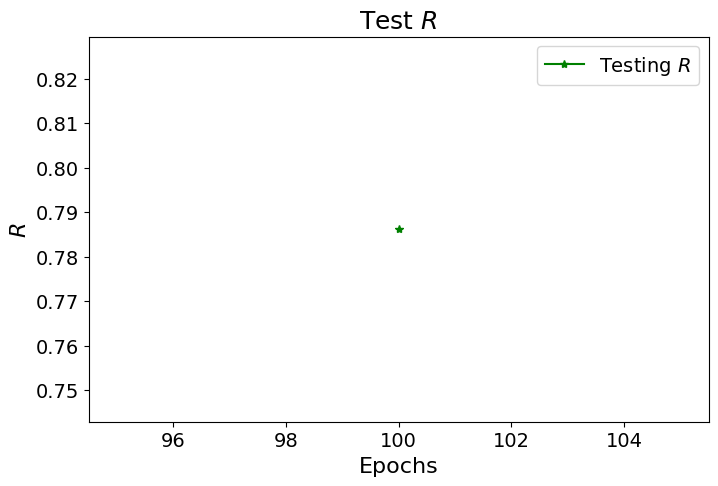

The highest test R is achieved at Epoch: 100


In [16]:
fig = plt.figure(figsize=(8, 5))
plt.plot(range(save_every, num_epochs+1, save_every), Test_R_all, 'g-*', label='Testing $R$')
plt.title('Test $R$', fontsize=18)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('$R$', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

epoch = int((np.where(Test_R_all == Test_R_all.max())[0][0] + 1) * save_every)
print(f'The highest test R is achieved at Epoch: {epoch}')


## Load trained MiTSformer regression models


In [17]:
select_epochs = 100


In [18]:
path = (
    f'./Saved_Model/MiTSformer_Model_{model_num}/'
    f'checkpoint_{select_epochs}.pt'
)
model.load_state_dict(
    torch.load(path, map_location=device)
)

hist_path = (
    f'./Saved_Model/MiTSformer_Model_{model_num}/'
    f'trainHistoryDict_{select_epochs}'
)
with open(hist_path, 'rb') as f:
    history = pickle.load(f)


## Evaluate using experimental testing dataset


In [19]:
# Evaluate using the experimental testing dataset
ExpTest_X = torch.tensor(
    ExpTest_Data_Pro, dtype=torch.float32
).to(device)
ExpTest_Dis, ExpTest_Con = make_mits_streams(ExpTest_X)

model.eval()
start_time = time.time()

with torch.no_grad():
    ExpTest_Pred_Pro = model(
        ExpTest_Dis, ExpTest_Con
    ).cpu().numpy()

print(
    f"Testing time: {(time.time() - start_time) / 60:.3f} min"
)

# De-normalize the predictions
ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

for i in range(ExpTest_Pred_Pro.shape[1]):
    ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * \
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])

# Mean square error
ExpTest_MSE_p1 = np.mean((ExpTest_Pred[:,0] - ExpTest_Label[:,0]) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1))

# R^2
ExpTest_R2_p1 = r2_score(ExpTest_Label[:,0], ExpTest_Pred[:,0])
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1))

# R
ExpTest_R_p1 = np.corrcoef(ExpTest_Label[:,0].astype(float), ExpTest_Pred[:,0].astype(float))[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1))

# Bias
ExpTest_Bias_p1 = np.mean(ExpTest_Pred[:,0]) - np.mean(ExpTest_Label[:,0])
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1))

Testing time: 0.001 min
p1 MSE on experimental tesing dataset: 24.5679067806
p1 R2 on experimental tesing dataset: -1.3424653550
p1 R on experimental tesing dataset: 0.4363283694
p1 Bias on experimental tesing dataset: -4.0023206472


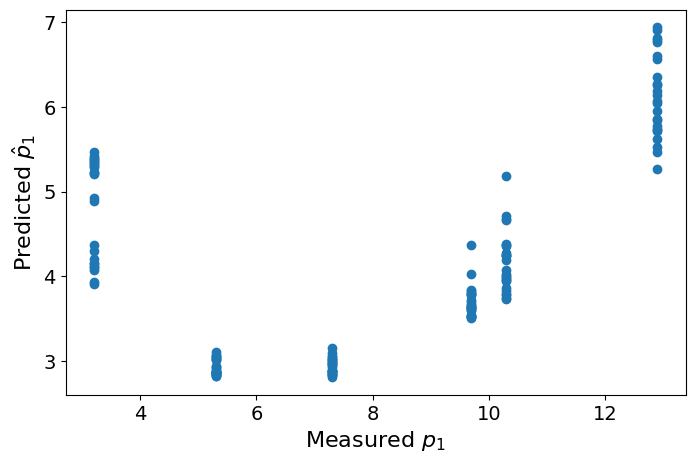

In [20]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,0],ExpTest_Pred[:,0])
plt.xlabel('Measured $p_1$',fontsize=16)
plt.ylabel('Predicted $\hat{p}_1$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [21]:
# Mean square error
ExpTest_MSE_c1 = np.mean((ExpTest_Pred[:,1] - ExpTest_Label[:,1]) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c1))

# R^2
ExpTest_R2_c1 = r2_score(ExpTest_Label[:,1], ExpTest_Pred[:,1])
print('c1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c1))

# R
ExpTest_R_c1 = np.corrcoef(ExpTest_Label[:,1].astype(float), ExpTest_Pred[:,1].astype(float))[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (ExpTest_R_c1))

# Bias
ExpTest_Bias_c1 = np.mean(ExpTest_Pred[:,1]) - np.mean(ExpTest_Label[:,1])
print('c1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c1))

c1 MSE on experimental tesing dataset: 0.0004001752
c1 R2 on experimental tesing dataset: -0.1644124528
c1 R on experimental tesing dataset: 0.7861974871
c1 Bias on experimental tesing dataset: -0.0150672136


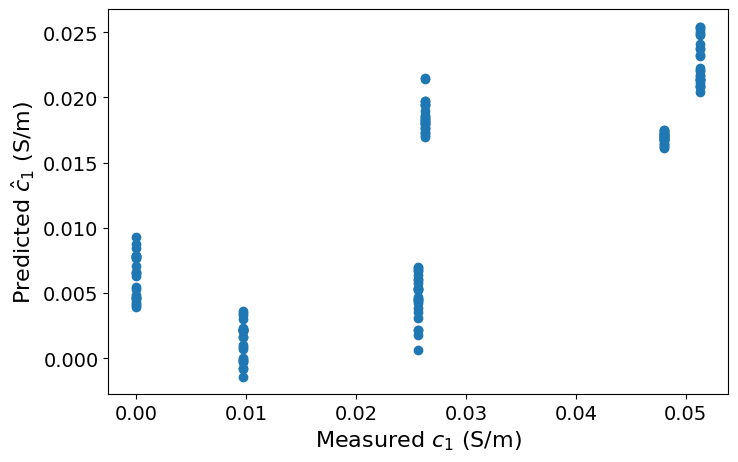

In [22]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,1],ExpTest_Pred[:,1])
plt.xlabel('Measured $c_1$ (S/m)',fontsize=16)
plt.ylabel('Predicted $\hat{c}_1$ (S/m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [23]:
# Mean square error
ExpTest_MSE_d1 = np.mean((ExpTest_Pred[:,2] - ExpTest_Label[:,2]) ** 2)
print('d1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_d1))

# R^2
ExpTest_R2_d1 = r2_score(ExpTest_Label[:,2], ExpTest_Pred[:,2])
print('d1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_d1))

# R
ExpTest_R_d1 = np.corrcoef(ExpTest_Label[:,2].astype(float), ExpTest_Pred[:,2].astype(float))[0,1]
print('d1 R on experimental tesing dataset: %.10f' % (ExpTest_R_d1))

# Bias
ExpTest_Bias_d1 = np.mean(ExpTest_Pred[:,2]) - np.mean(ExpTest_Label[:,2])
print('d1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_d1))

d1 MSE on experimental tesing dataset: 0.0025219909
d1 R2 on experimental tesing dataset: -818432843688864320580325736448.0000000000
d1 R on experimental tesing dataset: -0.0000000000
d1 Bias on experimental tesing dataset: 0.0496390147


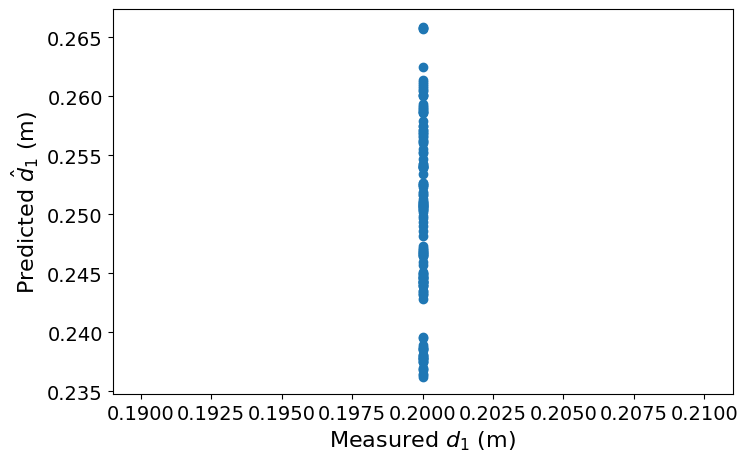

In [24]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,2],ExpTest_Pred[:,2])
plt.xlabel('Measured $d_1$ (m)',fontsize=16)
plt.ylabel('Predicted $\hat{d}_1$ (m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [25]:
specimen_1_pred_mean_p1 = np.mean(ExpTest_Pred[0:25,0])
specimen_2_pred_mean_p1 = np.mean(ExpTest_Pred[25:50,0])
specimen_3_pred_mean_p1 = np.mean(ExpTest_Pred[50:75,0])
specimen_4_pred_mean_p1 = np.mean(ExpTest_Pred[75:100,0])
specimen_5_pred_mean_p1 = np.mean(ExpTest_Pred[100:125,0])
specimen_6_pred_mean_p1 = np.mean(ExpTest_Pred[125:150,0])
ExpTest_Pred_Pro_p1 = np.array([specimen_1_pred_mean_p1,specimen_2_pred_mean_p1,specimen_3_pred_mean_p1,
                                    specimen_4_pred_mean_p1,specimen_5_pred_mean_p1,specimen_6_pred_mean_p1])
ExpTest_Label_Pro_p1 = np.array([ExpTest_Label[0,0],ExpTest_Label[25,0],ExpTest_Label[50,0],
                                    ExpTest_Label[75,0],ExpTest_Label[100,0],ExpTest_Label[125,0]])

In [26]:
# R^2
ExpTest_R2_p1 = r2_score(ExpTest_Label_Pro_p1,ExpTest_Pred_Pro_p1)
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1))

# Mean square error
ExpTest_MSE_p1 = np.mean((ExpTest_Pred_Pro_p1 - ExpTest_Label_Pro_p1) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1))

# R
ExpTest_R_p1 = np.corrcoef(ExpTest_Label_Pro_p1,ExpTest_Pred_Pro_p1)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1))

# Bias
ExpTest_Bias_p1 = np.mean(ExpTest_Pred_Pro_p1) - np.mean(ExpTest_Label_Pro_p1)
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1))

p1 R2 on experimental tesing dataset: -1.3306986380
p1 MSE on experimental tesing dataset: 24.4444967981
p1 R on experimental tesing dataset: 0.4573504825
p1 Bias on experimental tesing dataset: -4.0023206472


p1 R on experimental tesing dataset: 0.4573504825
p1 Bias on experimental tesing dataset: -4.0023206472
p1 MSE on experimental tesing dataset: 24.4444967981
p1 RMSE on experimental tesing dataset: 4.9441376193
p1 ubMSE on experimental tesing dataset: 2.9027446038


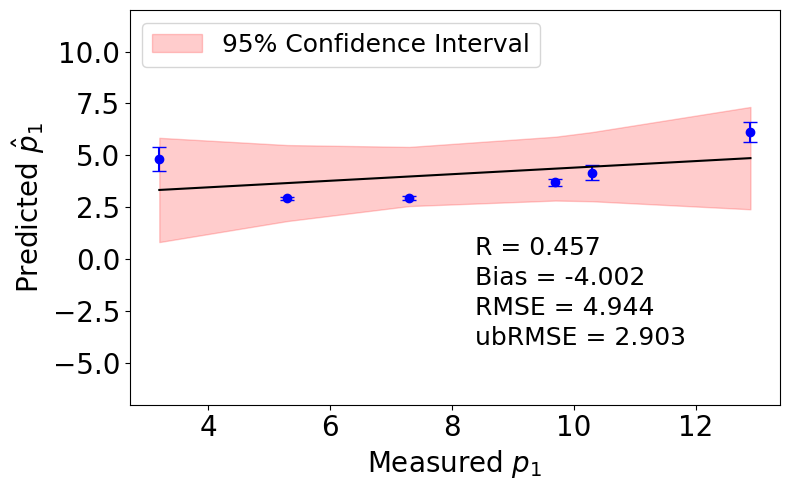

In [27]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[0:25,0])
mean_2 = np.mean(ExpTest_Pred[25:50,0])
mean_3 = np.mean(ExpTest_Pred[50:75,0])
mean_4 = np.mean(ExpTest_Pred[75:100,0])
mean_5 = np.mean(ExpTest_Pred[100:125,0])
mean_6 = np.mean(ExpTest_Pred[125:150,0])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[0:25,0])
std_2 = np.std(ExpTest_Pred[25:50,0])
std_3 = np.std(ExpTest_Pred[50:75,0])
std_4 = np.std(ExpTest_Pred[75:100,0])
std_5 = np.std(ExpTest_Pred[100:125,0])
std_6 = np.std(ExpTest_Pred[125:150,0])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,0],ExpTest_Label[25,0],ExpTest_Label[50,0],ExpTest_Label[75,0],ExpTest_Label[100,0],ExpTest_Label[125,0]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('p1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('p1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('p1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='red', alpha=0.2, label='95% Confidence Interval')

# Plotting the Prediction Interval (PI)
# plt.fill_between(label, pi_lower, pi_upper, color='black', alpha=0.2, label='95% Prediction Interval')

plt.xlabel('Measured $p_1$',fontsize=20)
plt.ylabel('Predicted $\hat{p}_1$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.6, 0.48, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.6, 0.42, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.6, 0.36, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.6, 0.30, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-7,12])
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Permittivity_MiTSformer', dpi=600)

In [28]:
specimen_1_pred_mean_c1 = np.mean(ExpTest_Pred[0:25,1])
specimen_2_pred_mean_c1 = np.mean(ExpTest_Pred[25:50,1])
specimen_3_pred_mean_c1 = np.mean(ExpTest_Pred[50:75,1])
specimen_4_pred_mean_c1 = np.mean(ExpTest_Pred[75:100,1])
specimen_5_pred_mean_c1 = np.mean(ExpTest_Pred[100:125,1])
specimen_6_pred_mean_c1 = np.mean(ExpTest_Pred[125:150,1])
ExpTest_Pred_Pro_c1 = np.array([specimen_1_pred_mean_c1,specimen_2_pred_mean_c1,specimen_3_pred_mean_c1,
                                    specimen_4_pred_mean_c1,specimen_5_pred_mean_c1,specimen_6_pred_mean_c1])
ExpTest_Label_Pro_c1 = np.array([ExpTest_Label[0,1],ExpTest_Label[25,1],ExpTest_Label[50,1],
                                    ExpTest_Label[75,1],ExpTest_Label[100,1],ExpTest_Label[125,1]])

In [29]:
# R^2
ExpTest_R2_c1 = r2_score(ExpTest_Label_Pro_c1,ExpTest_Pred_Pro_c1)
print('c1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c1))

# Mean square error
ExpTest_MSE_c1 = np.mean((ExpTest_Pred_Pro_c1 - ExpTest_Label_Pro_c1) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c1))

# R
ExpTest_R_c1 = np.corrcoef(ExpTest_Label_Pro_c1,ExpTest_Pred_Pro_c1)[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (ExpTest_R_c1))

# Bias
ExpTest_Bias_c1 = np.mean(ExpTest_Pred_Pro_c1) - np.mean(ExpTest_Label_Pro_c1)
print('c1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c1))

c1 R2 on experimental tesing dataset: -0.1586841922
c1 MSE on experimental tesing dataset: 0.0003982066
c1 R on experimental tesing dataset: 0.7982612216
c1 Bias on experimental tesing dataset: -0.0150672136


c1 R on experimental tesing dataset: 0.7982612216
c1 Bias on experimental tesing dataset: -0.0150672136
c1 MSE on experimental tesing dataset: 0.0003982066
c1 RMSE on experimental tesing dataset: 0.0199551148
c1 ubMSE on experimental tesing dataset: 0.0130837945


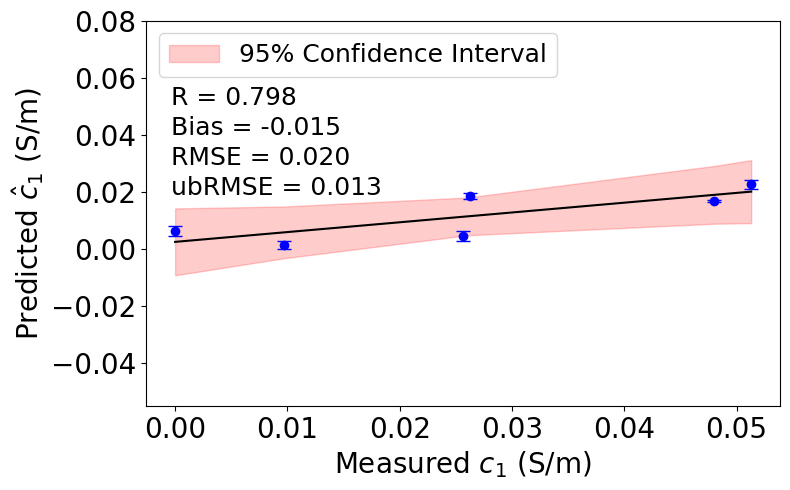

In [30]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[0:25,1])
mean_2 = np.mean(ExpTest_Pred[25:50,1])
mean_3 = np.mean(ExpTest_Pred[50:75,1])
mean_4 = np.mean(ExpTest_Pred[75:100,1])
mean_5 = np.mean(ExpTest_Pred[100:125,1])
mean_6 = np.mean(ExpTest_Pred[125:150,1])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[0:25,1])
std_2 = np.std(ExpTest_Pred[25:50,1])
std_3 = np.std(ExpTest_Pred[50:75,1])
std_4 = np.std(ExpTest_Pred[75:100,1])
std_5 = np.std(ExpTest_Pred[100:125,1])
std_6 = np.std(ExpTest_Pred[125:150,1])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,1],ExpTest_Label[25,1],ExpTest_Label[50,1],ExpTest_Label[75,1],ExpTest_Label[100,1],ExpTest_Label[125,1]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('c1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('c1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('c1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='red', alpha=0.2, label='95% Confidence Interval')

# Plotting the Prediction Interval (PI)
# plt.fill_between(label, pi_lower, pi_upper, color='black', alpha=0.2, label='95% Prediction Interval')

plt.xlabel('Measured $c_1$ (S/m)',fontsize=20)
plt.ylabel('Predicted $\hat{c}_1$ (S/m)',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.22, 0.78, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.22, 0.72, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.22, 0.66, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.22, 0.60, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-0.055,0.08])
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Conductivity_MiTSformer', dpi=600)

In [31]:
specimen_1_pred_mean_d1 = np.mean(ExpTest_Pred[0:25,2])
specimen_2_pred_mean_d1 = np.mean(ExpTest_Pred[25:50,2])
specimen_3_pred_mean_d1 = np.mean(ExpTest_Pred[50:75,2])
specimen_4_pred_mean_d1 = np.mean(ExpTest_Pred[75:100,2])
specimen_5_pred_mean_d1 = np.mean(ExpTest_Pred[100:125,2])
specimen_6_pred_mean_d1 = np.mean(ExpTest_Pred[125:150,2])
ExpTest_Pred_Pro_d1 = np.array([specimen_1_pred_mean_d1,specimen_2_pred_mean_d1,specimen_3_pred_mean_d1,
                                    specimen_4_pred_mean_d1,specimen_5_pred_mean_d1,specimen_6_pred_mean_d1])
ExpTest_Label_Pro_d1 = np.array([ExpTest_Label[0,2],ExpTest_Label[25,2],ExpTest_Label[50,2],
                                    ExpTest_Label[75,2],ExpTest_Label[100,2],ExpTest_Label[125,2]])

In [32]:
# R^2
ExpTest_R2_d1 = r2_score(ExpTest_Label_Pro_d1,ExpTest_Pred_Pro_d1)
print('d1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_d1))

# Mean square error
ExpTest_MSE_d1 = np.mean((ExpTest_Pred_Pro_d1 - ExpTest_Label_Pro_d1) ** 2)
print('d1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_d1))

# R
ExpTest_R_d1 = np.corrcoef(ExpTest_Label_Pro_d1,ExpTest_Pred_Pro_d1)[0,1]
print('d1 R on experimental tesing dataset: %.10f' % (ExpTest_R_d1))

# Bias
ExpTest_Bias_d1 = np.mean(ExpTest_Pred_Pro_d1) - np.mean(ExpTest_Label_Pro_d1)
print('d1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_d1))

# RMSE
ExpTest_RMSE_d1 = np.sqrt(ExpTest_MSE_d1)
print('d1 RMSE on experimental tesing dataset: %.10f' % (ExpTest_RMSE_d1))

# ubRMSE
ExpTest_ubRMSE_d1 = np.sqrt((ExpTest_RMSE_d1 ** 2 - ExpTest_Bias_d1 ** 2))
print('d1 ubRMSE on experimental tesing dataset: %.10f' % (ExpTest_ubRMSE_d1))

d1 R2 on experimental tesing dataset: -3263646168772667474389577498624.0000000000
d1 MSE on experimental tesing dataset: 0.0025142216
d1 R on experimental tesing dataset: -0.0000000000
d1 Bias on experimental tesing dataset: 0.0496390147
d1 RMSE on experimental tesing dataset: 0.0501420139
d1 ubRMSE on experimental tesing dataset: 0.0070844741


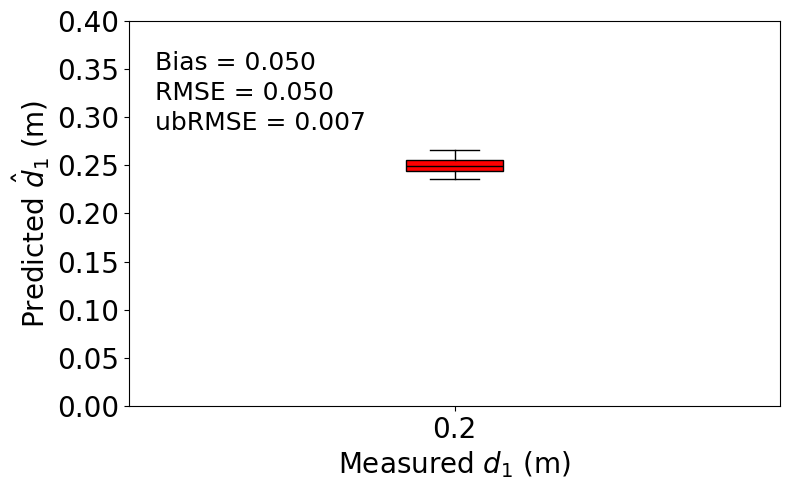

In [35]:
# Box plot
fig = plt.figure(figsize=(8, 5))
box = plt.boxplot(ExpTest_Pred[:,2],patch_artist=True,meanline=True,showmeans=True)
# fill with colors
for patch in box['boxes']:
    patch.set_facecolor('red')
for mean in box['means']:
    mean.set_color('black')
    mean.set_linestyle('solid')
for median in box['medians']:
    median.set_linewidth(0)

plt.xlabel('Measured $d_1$ (m)',fontsize=20)
plt.ylabel('Predicted $\hat{d}_1$ (m)',fontsize=20)
labels = ['0.2']
plt.xticks([1], labels, fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.ylim([0,0.4])
plt.figtext(0.2, 0.85, f'Bias = %.3f' % ExpTest_Bias_d1, fontsize=18)
plt.figtext(0.2, 0.79, f'RMSE = %.3f' % ExpTest_RMSE_d1, fontsize=18)
plt.figtext(0.2, 0.73, f'ubRMSE = %.3f' % ExpTest_ubRMSE_d1, fontsize=18)
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Depth_MiTSformer', dpi=600)

In [36]:
np.std(ExpTest_Pred[:,2])

0.007613089603945269